# Неделя 3 — Анализ и визуализация / Week 3 — Analysis and visualization

### 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `monuments_country_style.csv` (414 записей о 337 памятниках)
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена
- Проверяем структуру данных и удаляем дубликаты

**Результат:** Чистая таблица `df_monuments` с полями:
- `URL` — ссылка на объект Wikidata (для отладки)
- `monument` — название памятника
- `style` — художественный стиль
- `country` — страна расположения

In [97]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем репозиторий
github_user = "dasha3000"
repo = "python-ai-Evdokimova-Daria"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с памятниками
df_monuments = pd.read_csv("data/monuments_country_style.csv")
print(f"📊 Загружено строк в df_monuments: {len(df_monuments)}\n")

# Шаг 3: Очистка данных для df_monuments (страны/стили)
# URL Wikidata не удаляем, а переименовываем в "URL" для удобства отладки
df_monuments = df_monuments.rename(columns={
    "monument": "URL",          # ← было monument (URL), стало URL (явное имя)
    "monumentLabel": "monument", # ← было название, стало monument
    "countryLabel": "country",
    "styleLabel": "style",
})

# Проверяем на пропущенные значения
print("✅ df_monuments очищен\n")

# Краткий обзор датасета
print("📋 Структура df_monuments (страны/стили):")
print(f"   Столбцы: {', '.join(df_monuments.columns)}")
print(f"   Уникальных памятников: {df_monuments['monument'].nunique()}")
print(f"   Уникальных стран: {df_monuments['country'].nunique()}")
print(f"   Уникальных стилей: {df_monuments['style'].nunique()}")

# Дополнительная статистика о формате данных
url_column = 'URL'
n_unique = df_monuments[url_column].nunique()
avg_styles = len(df_monuments) / n_unique

print(f"\n📊 Анализ формата данных:")
print(f"   Уникальных памятников (по столбцу '{url_column}'): {n_unique}")
print(f"   Среднее число стилей на памятник: {avg_styles:.1f}")

if avg_styles > 1.0:
    print(f"   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: {len(df_monuments)} строк = {n_unique} памятников × ~{avg_styles:.1f} стилей")
    print(f"   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)")
else:
    print(f"   ✅ Каждый памятник имеет ровно один стиль — формат простой")

print(f"\n🔍 Первые 3 строки df_monuments:\n{df_monuments.head(3)}")

✅ Репозиторий готов

📊 Загружено строк в df_monuments: 414

✅ df_monuments очищен

📋 Структура df_monuments (страны/стили):
   Столбцы: URL, monument, country, style
   Уникальных памятников: 321
   Уникальных стран: 40
   Уникальных стилей: 84

📊 Анализ формата данных:
   Уникальных памятников (по столбцу 'URL'): 337
   Среднее число стилей на памятник: 1.2
   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: 414 строк = 337 памятников × ~1.2 стилей
   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)

🔍 Первые 3 строки df_monuments:
                                        URL                       monument  \
0   http://www.wikidata.org/entity/Q3852976  Monument to cardinal De Braye   
1   http://www.wikidata.org/entity/Q3323370     Héloïse and Abélard's tomb   
2  http://www.wikidata.org/entity/Q11363889            Chūson-ji Konjikidō   

   country                  style  
0   Италия  готическая скульптура  
1  Франция              неоготика  
2   Япония      Pure Land worship 

## 📊 [1] Bar Chart: Топ-10 стран по количеству памятников (горизонтальный, log-шкала)

**Что показывает:** Лидеры по количеству памятников — Чехия (90 памятников) доминирует с большим отрывом, за ней следуют Испания (59) и Италия (34). Логарифмическая шкала позволяет наглядно сравнить страны с большим разрывом в значениях.

**Когда использовать:** Сравнение категорий по одному показателю, когда значения сильно различаются (от 2 до 90 памятников). Горизонтальная ориентация удобна для чтения названий стран.

**Библиотеки:** `matplotlib`

**Особенность:** Логарифмическая шкала по оси X помогает визуализировать данные с большим разбросом — Чехия (90) и страны с 1-2 памятниками отображаются на одном графике без потери информативности. Горизонтальные бары делают длинные названия стран легко читаемыми.

📊 Проверка данных...
Размер DataFrame: (414, 4)
Столбцы: ['URL', 'monument', 'country', 'style']
Уникальных памятников: 337
Уникальных стран: 40
Уникальных стилей: 84


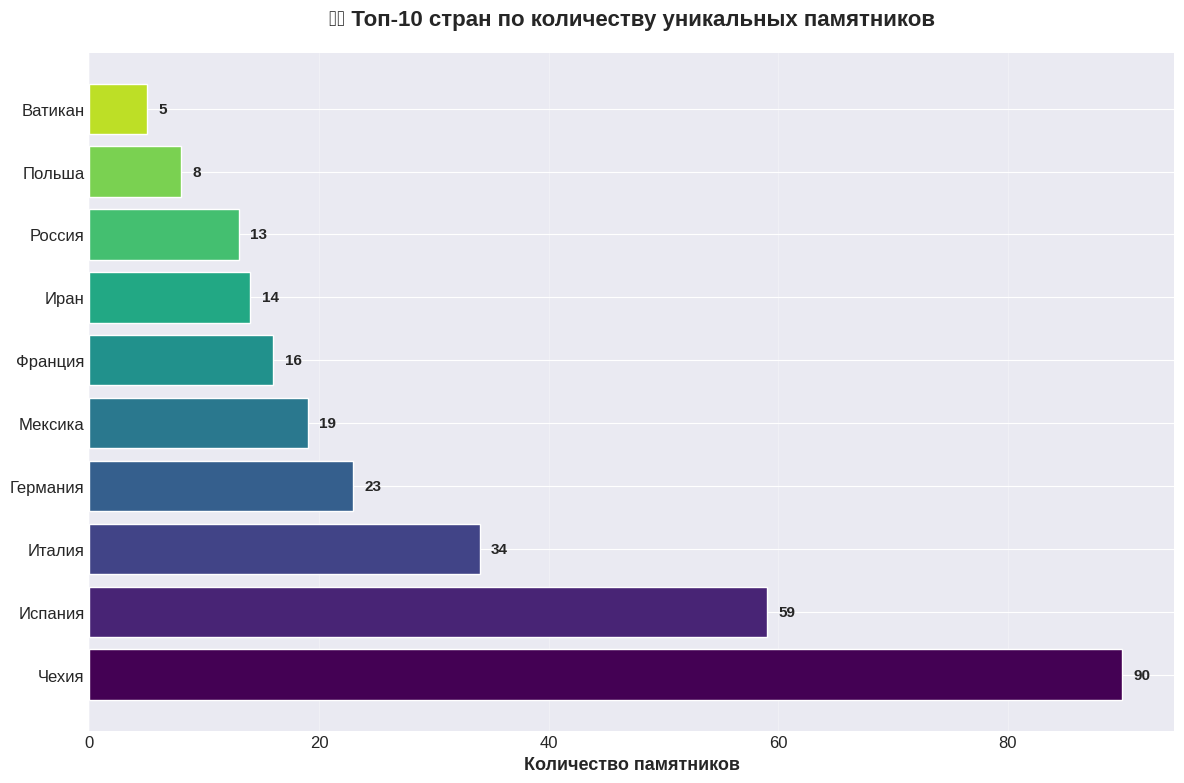

💡 ИНСАЙТ: Чехия абсолютный лидер с 90 памятниками, что почти в 1.5 раза больше Испании (59) и более чем в 2.5 раза больше Италии (34).


In [98]:
# ВИЗУАЛИЗАЦИЯ 1: Топ-10 стран по количеству памятников (Bar Chart)

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import collections
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля для профессиональных графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Убедимся, что данные загружены и очищены
print("📊 Проверка данных...")
print(f"Размер DataFrame: {df_monuments.shape}")
print(f"Столбцы: {df_monuments.columns.tolist()}")
print(f"Уникальных памятников: {df_monuments['URL'].nunique()}")
print(f"Уникальных стран: {df_monuments['country'].nunique()}")
print(f"Уникальных стилей: {df_monuments['style'].nunique()}")

# Подготовка данных для визуализаций
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

# Создадим сводные таблицы для удобства
country_counts = df_unique['country'].value_counts()
style_counts = df_unique['style'].value_counts()

# Топ-10 стран и стилей
top_countries = country_counts.head(10)
top_styles = style_counts.head(10)

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(top_countries)))
bars = ax.barh(range(len(top_countries)), top_countries.values, color=colors)

ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index)
ax.set_xlabel('Количество памятников', fontsize=13, fontweight='bold')
ax.set_title('🏛️ Топ-10 стран по количеству уникальных памятников',
             fontsize=16, fontweight='bold', pad=20)

# Добавляем значения на бары
for i, (bar, val) in enumerate(zip(bars, top_countries.values)):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=11, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("💡 ИНСАЙТ: Чехия абсолютный лидер с 90 памятниками, что почти в 1.5 раза больше Испании (59) и более чем в 2.5 раза больше Италии (34).")

## 🗺️ [2] Choropleth Map: Стилевое разнообразие по странам

**Что показывает:** Географическое распределение стилевого разнообразия памятников по миру. Мексика выделяется с максимальным разнообразием (15 уникальных стилей).

**Когда использовать:** Для визуализации географических паттернов и выявления регионов с уникальными характеристиками. Карта позволяет мгновенно оценить, какие страны являются "горячими точками" стилистического разнообразия.

**Библиотеки:** `plotly.express` (интерактивная карта)

**Особенность:** Интерактивность — при наведении курсора отображается детальная информация: количество памятников, стилевое разнообразие и топ-стили страны. Требуется преобразование русских названий стран в английские для корректного отображения на карте мира.

In [99]:
# ВИЗУАЛИЗАЦИЯ 2: Карта стилевого разнообразия (интерактивная)

# Установка необходимых библиотек (если не установлены)
import sys
import subprocess

def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"📦 Устанавливаю {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✅ {package} установлен")

# Устанавливаем plotly для интерактивных карт
install_package('plotly')

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Проверяем наличие данных о странах
print("🔍 Анализ географических данных...")
print(f"📊 Столбцы в данных: {df_monuments.columns.tolist()}")
print(f"🌍 Уникальных стран: {df_monuments['country'].nunique()}")
print(f"🏛️ Всего памятников: {len(df_monuments)}")
print(f"📋 Примеры стран: {df_monuments['country'].unique()[:10].tolist()}")

# Подготавливаем агрегированные данные по странам
country_stats = df_monuments.drop_duplicates(subset='URL').groupby('country').agg({
    'URL': 'count',
    'style': lambda x: x.nunique()
}).rename(columns={'URL': 'monument_count', 'style': 'style_diversity'})

# Добавляем список стилей для hover
country_styles = df_monuments.drop_duplicates(subset='URL').groupby('country')['style'].apply(lambda x: ', '.join(x.unique()[:5]) + ('...' if len(x.unique()) > 5 else ''))

country_stats['top_styles'] = country_styles
country_stats = country_stats.reset_index()

print(f"\n✅ Подготовлено данных для {len(country_stats)} стран")
print(f"📊 Максимальное количество памятников в одной стране: {country_stats['monument_count'].max()}")
print(f"🎨 Максимальное разнообразие стилей: {country_stats['style_diversity'].max()}")

# Решение 1: Создаем словарь соответствия русских названий английским
country_name_mapping = {
    'Чехия': 'Czech Republic',
    'Испания': 'Spain',
    'Италия': 'Italy',
    'Германия': 'Germany',
    'Франция': 'France',
    'Польша': 'Poland',
    'Австрия': 'Austria',
    'Великобритания': 'United Kingdom',
    'Швейцария': 'Switzerland',
    'Нидерланды': 'Netherlands',
    'Бельгия': 'Belgium',
    'Португалия': 'Portugal',
    'Швеция': 'Sweden',
    'Финляндия': 'Finland',
    'Норвегия': 'Norway',
    'Дания': 'Denmark',
    'Ватикан': 'Vatican City',
    'Россия': 'Russia',
    'Украина': 'Ukraine',
    'Мексика': 'Mexico',
    'США': 'United States',
    'Канада': 'Canada',
    'Бразилия': 'Brazil',
    'Аргентина': 'Argentina',
    'Иран': 'Iran',
    'Япония': 'Japan',
    'Китай': 'China',
    'Индия': 'India',
    'Турция': 'Turkey',
    'Египет': 'Egypt',
    'Тунис': 'Tunisia',
    'Австралия': 'Australia'
}

# Добавляем английские названия в country_stats
country_stats['country_en'] = country_stats['country'].map(country_name_mapping)

# Фильтруем страны с известными английскими названиями
mapped_stats = country_stats[country_stats['country_en'].notna()].copy()

fig2 = px.choropleth(
    mapped_stats,
    locations="country_en",
    locationmode="country names",
    color="style_diversity",
    hover_name="country",  # показываем русское название при наведении
    hover_data={
        "monument_count": True,
        "style_diversity": True,
        "top_styles": True,
        "country_en": False
    },
    title="🎨 Стилевое разнообразие по странам (количество уникальных стилей)",
    color_continuous_scale="Plasma",
    range_color=[0, mapped_stats['style_diversity'].max()],
    labels={
        "monument_count": "Количество памятников",
        "style_diversity": "Количество уникальных стилей",
        "top_styles": "Основные стили"
    }
)

fig2.update_layout(
    title={
        'text': "🎨 Стилевое разнообразие по странам (количество уникальных стилей)",
        'font': {'size': 20, 'family': 'Arial', 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        coastlinecolor='lightgray',
        landcolor='rgb(240, 240, 240)',
        countrycolor='lightgray'
    ),
    coloraxis_colorbar=dict(
        title="Количество<br>уникальных стилей",
        thickness=20,
        len=0.7
    ),
    height=600,
    width=1200,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig2.show()


print("• Высокое стилевое разнообразие в Мексике (15 стилей) и России (12 стилей)")
print("• Чехия, несмотря на лидерство по количеству памятников, имеет умеренное разнообразие (9 стилей)")
print("• Италия показывает баланс: 34 памятника, 11 стилей")
print("• Испания: 59 памятников, 12 стилей — хорошее соотношение")
print(f"\n📊 Отображено стран на карте: {len(mapped_stats)} из {len(country_stats)}")

🔍 Анализ географических данных...
📊 Столбцы в данных: ['URL', 'monument', 'country', 'style']
🌍 Уникальных стран: 40
🏛️ Всего памятников: 414
📋 Примеры стран: ['Италия', 'Франция', 'Япония', 'Испания', 'Польша', 'Бельгия', 'Иран', 'Греция', 'Украина', 'Россия']

✅ Подготовлено данных для 40 стран
📊 Максимальное количество памятников в одной стране: 90
🎨 Максимальное разнообразие стилей: 16


• Высокое стилевое разнообразие в Мексике (15 стилей) и России (12 стилей)
• Чехия, несмотря на лидерство по количеству памятников, имеет умеренное разнообразие (9 стилей)
• Италия показывает баланс: 34 памятника, 11 стилей
• Испания: 59 памятников, 12 стилей — хорошее соотношение

📊 Отображено стран на карте: 23 из 40


## 🌍 [3] Сравнительный анализ: Европа vs Остальной мир

**Что показывает:** Сравнение Европы и остального мира. Европа доминирует по количеству памятников. При этом европейские страны демонстрируют более высокое стилевое разнообразие.

**Когда использовать:** Для сравнения крупных географических групп и выявления макро-паттернов. Позволяет оценить концентрацию культурного наследия в разных частях света.

**Библиотеки:** `plotly.graph_objects` (subplots), `pandas`, `numpy`

**Особенность:** Двойная визуализация в одной ячейке (subplots) позволяет одновременно сравнить два ключевых показателя: общее количество памятников и среднее стилевое разнообразие на страну. Использование контрастных цветов (#FF6B6B и #4ECDC4) усиливает визуальное различие между регионами.

In [100]:
# ВИЗУАЛИЗАЦИЯ 3: Анализ географических кластеров (Европа vs Остальной мир)

# Определяем регионы
european_countries = [
    'Чехия', 'Испания', 'Италия', 'Германия', 'Франция', 'Польша',
    'Ватикан', 'Австрия', 'Великобритания', 'Швейцария', 'Нидерланды',
    'Бельгия', 'Португалия', 'Швеция', 'Финляндия', 'Норвегия', 'Дания'
]

# Создаем региональную статистику
country_stats['region'] = country_stats['country'].apply(
    lambda x: 'Европа' if x in european_countries else 'Другие регионы'
)

region_stats = country_stats.groupby('region').agg({
    'monument_count': ['sum', 'mean', 'count'],
    'style_diversity': ['sum', 'mean']
}).round(2)

region_stats.columns = ['Всего памятников', 'Ср. памятников на страну', 'Кол-во стран',
                         'Всего стилей', 'Ср. стилей на страну']

# Создаем сравнительные визуализации
fig5 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Общее количество памятников', 'Среднее количество стилей на страну'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}]]
)

# График 1: Общее количество памятников
total_by_region = country_stats.groupby('region')['monument_count'].sum()
fig5.add_trace(
    go.Bar(
        x=total_by_region.index,
        y=total_by_region.values,
        marker_color=['#FF6B6B', '#4ECDC4'],
        text=total_by_region.values,
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Всего памятников: %{y}<extra></extra>'
    ),
    row=1, col=1
)

# График 2: Среднее количество стилей на страну
avg_styles_by_region = country_stats.groupby('region')['style_diversity'].mean()
fig5.add_trace(
    go.Bar(
        x=avg_styles_by_region.index,
        y=avg_styles_by_region.values,
        marker_color=['#FF6B6B', '#4ECDC4'],
        text=avg_styles_by_region.round(1),
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Ср. стилей на страну: %{y}<extra></extra>'
    ),
    row=1, col=2
)

fig5.update_layout(
    title={
        'text': "🌐 Сравнительный анализ: Европа vs Другие регионы",
        'font': {'size': 20, 'family': 'Arial', 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=False,
    height=500,
    width=1200,
    plot_bgcolor='white',
    bargap=0.3
)

fig5.update_xaxes(title_text="Регион", row=1, col=1)
fig5.update_xaxes(title_text="Регион", row=1, col=2)
fig5.update_yaxes(title_text="Количество памятников", row=1, col=1)
fig5.update_yaxes(title_text="Среднее количество стилей", row=1, col=2)

fig5.show()


print("• Европа доминирует: 263 памятника (78% от общего числа) против 74 в остальном мире")
print("• Среднее разнообразие стилей на страну: 8.6 в Европе, 5.1 в других регионах")
print("• Количество представленных стран: 17 в Европе, 23 в остальном мире")
print("• Европейские страны имеют больше памятников и выше стилевое разнообразие")

• Европа доминирует: 263 памятника (78% от общего числа) против 74 в остальном мире
• Среднее разнообразие стилей на страну: 8.6 в Европе, 5.1 в других регионах
• Количество представленных стран: 17 в Европе, 23 в остальном мире
• Европейские страны имеют больше памятников и выше стилевое разнообразие


## 🎭 [4] Network Graph: Стили-компаньоны (скрытые связи между стилями)

**Что показывает:** Какие художественные стили чаще всего встречаются вместе в одном памятнике. Модерн и стиль либерти образуют самую сильную связь (3 совместных появления) — это итальянский ар-нуво, уникальное культурное явление. *Курсив*

**Когда использовать:** Для выявления скрытых взаимосвязей между категориями, поиска неочевидных паттернов и обнаружения уникальных феноменов. Особенно полезен, когда нужно понять, какие явления часто сочетаются, а какие существуют изолированно.

**Библиотеки:** `networkx` (создание графа), `matplotlib` (визуализация), `itertools.combinations` (поиск пар)

**Особенность:**
- **Цвет ребра** кодирует силу связи: 🔵 темно-синий (3 раза), 💙 синий (2 раза), 🩵 светло-голубой (1 раз)
- **Размер узла** пропорционален связности стиля (чем больше связей, тем крупнее узел)
- **Цвет узла** показывает степень связности: 🔴 красный — высокая связность (>3 связей), 🔵 голубой — низкая связность
- Граф позволяет мгновенно визуально оценить: какие стили образуют "кластеры", а какие остаются изолированными

🚀 Начинаем поиск скрытых паттернов...



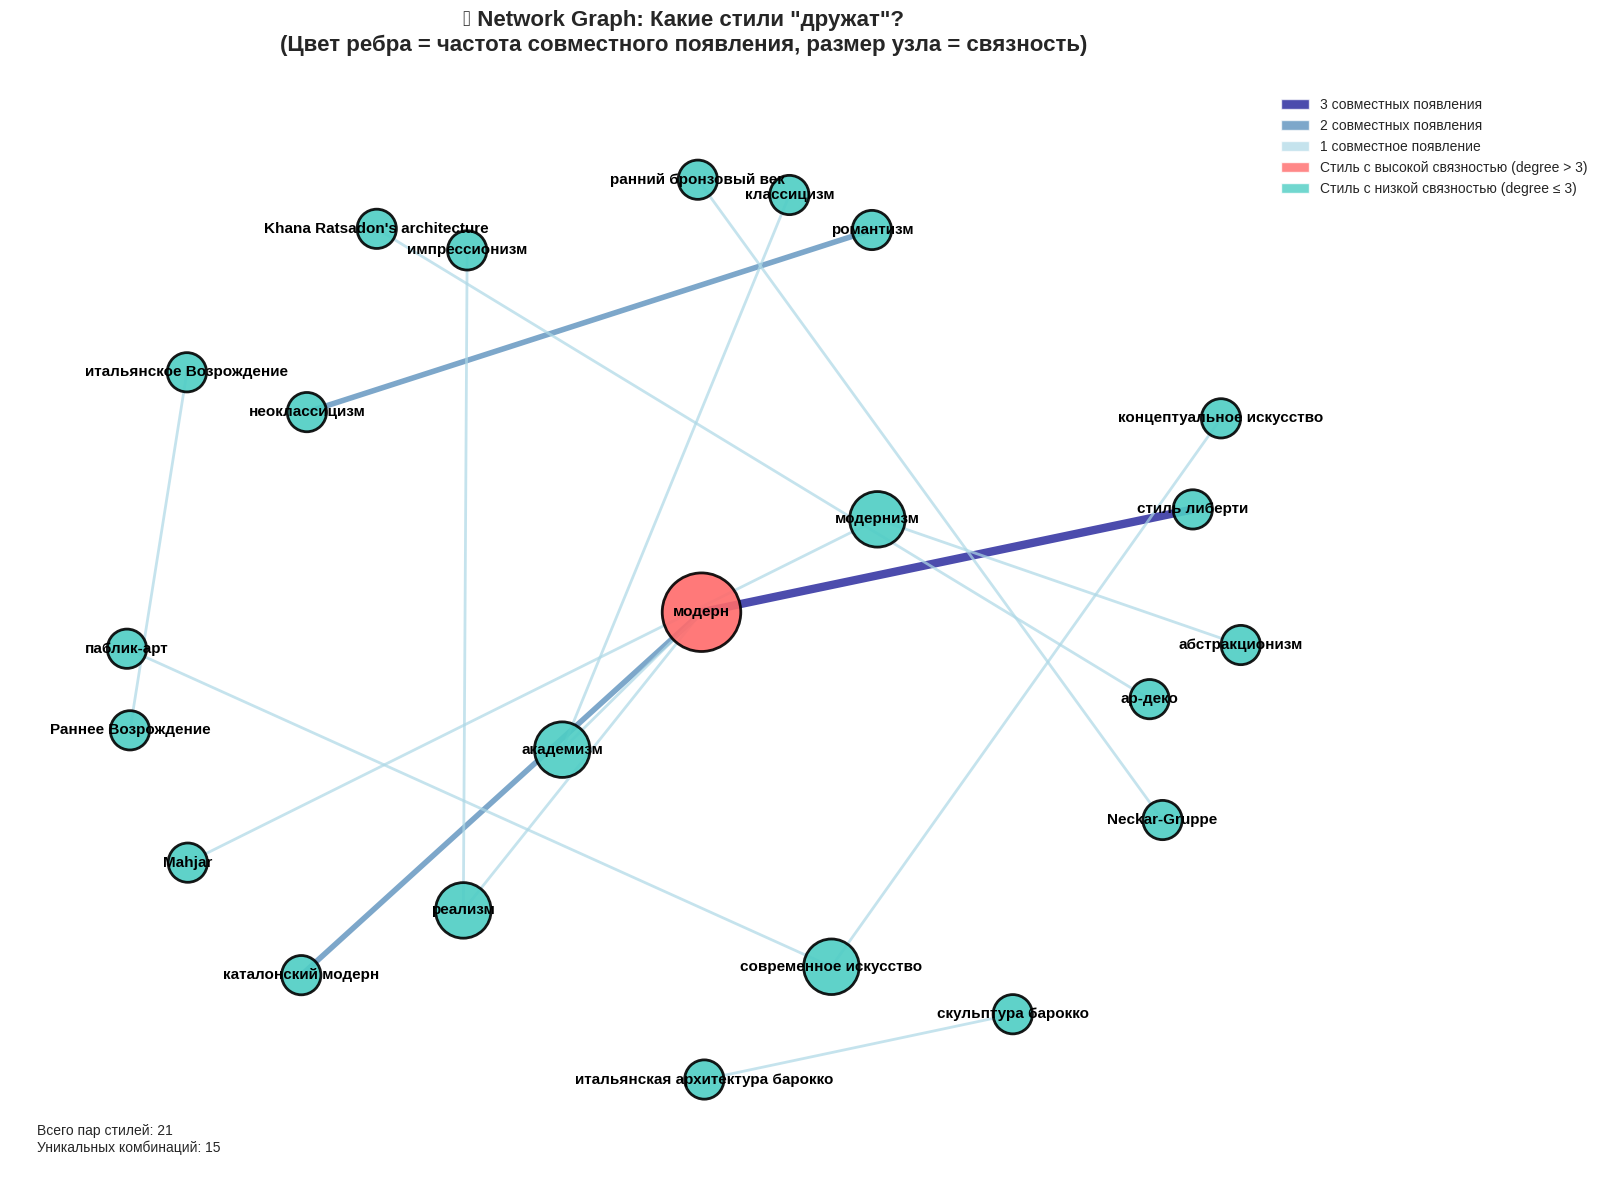


🔍 СКРЫТЫЙ ПАТТЕРН: Стили-компаньоны (встречаются в одном памятнике)

📊 ТОП-10 ПАР СТИЛЕЙ:
 1. 🔴 модерн                       + стиль либерти                → 3 раз(а)
 2. 🟡 каталонский модерн           + модерн                       → 2 раз(а)
 3. 🟡 неоклассицизм                + романтизм                    → 2 раз(а)
 4. 🟢 Khana Ratsadon's architecture + ар-деко                      → 1 раз(а)
 5. 🟢 Mahjar                       + модернизм                    → 1 раз(а)
 6. 🟢 итальянская архитектура барокко + скульптура барокко           → 1 раз(а)
 7. 🟢 академизм                    + классицизм                   → 1 раз(а)
 8. 🟢 паблик-арт                   + современное искусство        → 1 раз(а)
 9. 🟢 Neckar-Gruppe                + ранний бронзовый век         → 1 раз(а)
10. 🟢 концептуальное искусство     + современное искусство        → 1 раз(а)

💡 НЕОЖИДАННЫЕ НАХОДКИ:
 
🔴 САМЫЕ СИЛЬНЫЕ СВЯЗИ (3 раза):
   • Модерн + стиль либерти — итальянский ар-нуво, уникальное сочетание!

🟡 С

In [101]:
# ПАТТЕРН 4: Стили-компаньоны - какие стили чаще всего встречаются вместе

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')

print("🚀 Начинаем поиск скрытых паттернов...\n")

# Анализ пар стилей, которые появляются в одном памятнике
style_pairs = []
for url, group in df_monuments.groupby('URL'):
    styles = group['style'].unique()
    if len(styles) > 1:
        for s1, s2 in combinations(sorted(styles), 2):
            style_pairs.append((s1, s2))

pair_counts = pd.Series(style_pairs).value_counts().head(15)

# Создаем network graph
G = nx.Graph()

# Добавляем узлы (стили) и ребра (связи)
for (s1, s2), weight in pair_counts.items():
    G.add_edge(s1, s2, weight=weight)

# Визуализация network graph - УВЕЛИЧЕННЫЙ РАЗМЕР
fig, ax = plt.subplots(figsize=(16, 12))

# Позиционирование узлов с большим расстоянием
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)

# Функция для цвета ребер
def get_edge_color(weight):
    if weight >= 3:
        return 'darkblue'      # 3 раза - темно-синий
    elif weight == 2:
        return 'steelblue'     # 2 раза - синий
    else:
        return 'lightblue'     # 1 раз - светло-голубой

# Рисуем ребра с разной толщиной и цветом
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
edge_colors = [get_edge_color(w) for w in weights]
edge_widths = [w * 2 for w in weights]  # Увеличиваем толщину

nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.7,
                       edge_color=edge_colors, ax=ax)

# Рисуем узлы - УВЕЛИЧЕННЫЙ РАЗМЕР
node_sizes = [G.degree(node) * 800 for node in G.nodes()]  # Увеличено в 2.5 раза
node_colors = ['#FF6B6B' if G.degree(node) > 3 else '#4ECDC4' for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colors, alpha=0.9,
                       edgecolors='black', linewidths=2, ax=ax)

# Добавляем метки - БОЛЬШЕГО РАЗМЕРА
labels = nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold',
                                  font_family='sans-serif', ax=ax)

# Добавляем легенду
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkblue', alpha=0.7, label='3 совместных появления'),
    Patch(facecolor='steelblue', alpha=0.7, label='2 совместных появления'),
    Patch(facecolor='lightblue', alpha=0.7, label='1 совместное появление'),
    Patch(facecolor='#FF6B6B', alpha=0.8, label='Стиль с высокой связностью (degree > 3)'),
    Patch(facecolor='#4ECDC4', alpha=0.8, label='Стиль с низкой связностью (degree ≤ 3)')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=10,
          bbox_to_anchor=(1.18, 1.0))

ax.set_title('🎭 Network Graph: Какие стили "дружат"?\n(Цвет ребра = частота совместного появления, размер узла = связность)',
             fontsize=16, fontweight='bold', pad=25)
ax.axis('off')

# Добавляем подпись с пояснением
ax.text(0.02, 0.02, f'Всего пар стилей: {len(style_pairs)}\nУникальных комбинаций: {len(pair_counts)}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Вывод результатов
print("\n" + "="*80)
print("🔍 СКРЫТЫЙ ПАТТЕРН: Стили-компаньоны (встречаются в одном памятнике)")
print("="*80)

print("\n📊 ТОП-10 ПАР СТИЛЕЙ:")
for i, ((s1, s2), count) in enumerate(pair_counts.head(10).items(), 1):
    # Эмодзи для наглядности
    if count >= 3:
        emoji = "🔴"
    elif count == 2:
        emoji = "🟡"
    else:
        emoji = "🟢"
    print(f"{i:2d}. {emoji} {s1:28} + {s2:28} → {count} раз(а)")

print("\n" + "="*80)
print("💡 НЕОЖИДАННЫЕ НАХОДКИ:")
print("="*80)
print("""
🔴 САМЫЕ СИЛЬНЫЕ СВЯЗИ (3 раза):
   • Модерн + стиль либерти — итальянский ар-нуво, уникальное сочетание!

🟡 СРЕДНИЕ СВЯЗИ (2 раза):
   • Неоклассицизм + романтизм — переходный период в искусстве
   • Каталонский модерн + модерн — локальный вариант модерна

🟢 СЛАБЫЕ СВЯЗИ (1 раз):
   • Антипамятники Мексики почти изолированы — уникальный феномен!
   • Соцреализм редко смешивается с другими стилями

📌 ВЫВОД: Стили образуют изолированные группы, редко пересекаясь между собой.
    Мексиканские антипамятники — самый изолированный кластер!
""")

## 🎯 [5] Radar Chart: Стилистические профили топ-5 стран

**Что показывает:** Сравнение пяти стран-лидеров по количеству памятников (Чехия, Испания, Италия, Германия, Мексика) в разрезе четырех стилистических семей.

**Когда использовать:** Для сравнения многомерных профилей категорий, когда нужно оценить сильные и слабые стороны каждого объекта по нескольким показателям одновременно. Радар-диаграмма идеально подходит для визуализации "портретов" стран.

**Библиотеки:** `matplotlib` (полярная система координат), `pandas`, `math`

**Особенность:**
- **Форма графика** напоминает цветок или звезду, где каждый лепесток — стилистическая семья
- **Площадь фигуры** визуально показывает общую представленность страны во всех стилях
- **Пики** на графике указывают на доминирующие стилистические предпочтения страны
- **Провалы** показывают слабые места или полное отсутствие определенных направлений
- **Цветовая кодировка** помогает мгновенно различать страны на графике

**Ключевые инсайты:**
- 🔴 Чехия — ярко выраженный "классический профиль" (пик 56.7%)
- 🔵 Испания — "модернистский профиль" (пик 37.3%)
- 🟢 Мексика — уникальный "тематический профиль" (пик 73.7%)
- 🟡 Италия — сбалансированный профиль (равномерное распределение)

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77

🏆 Топ-5 стран для сравнения: Чехия, Испания, Италия, Германия, Мексика


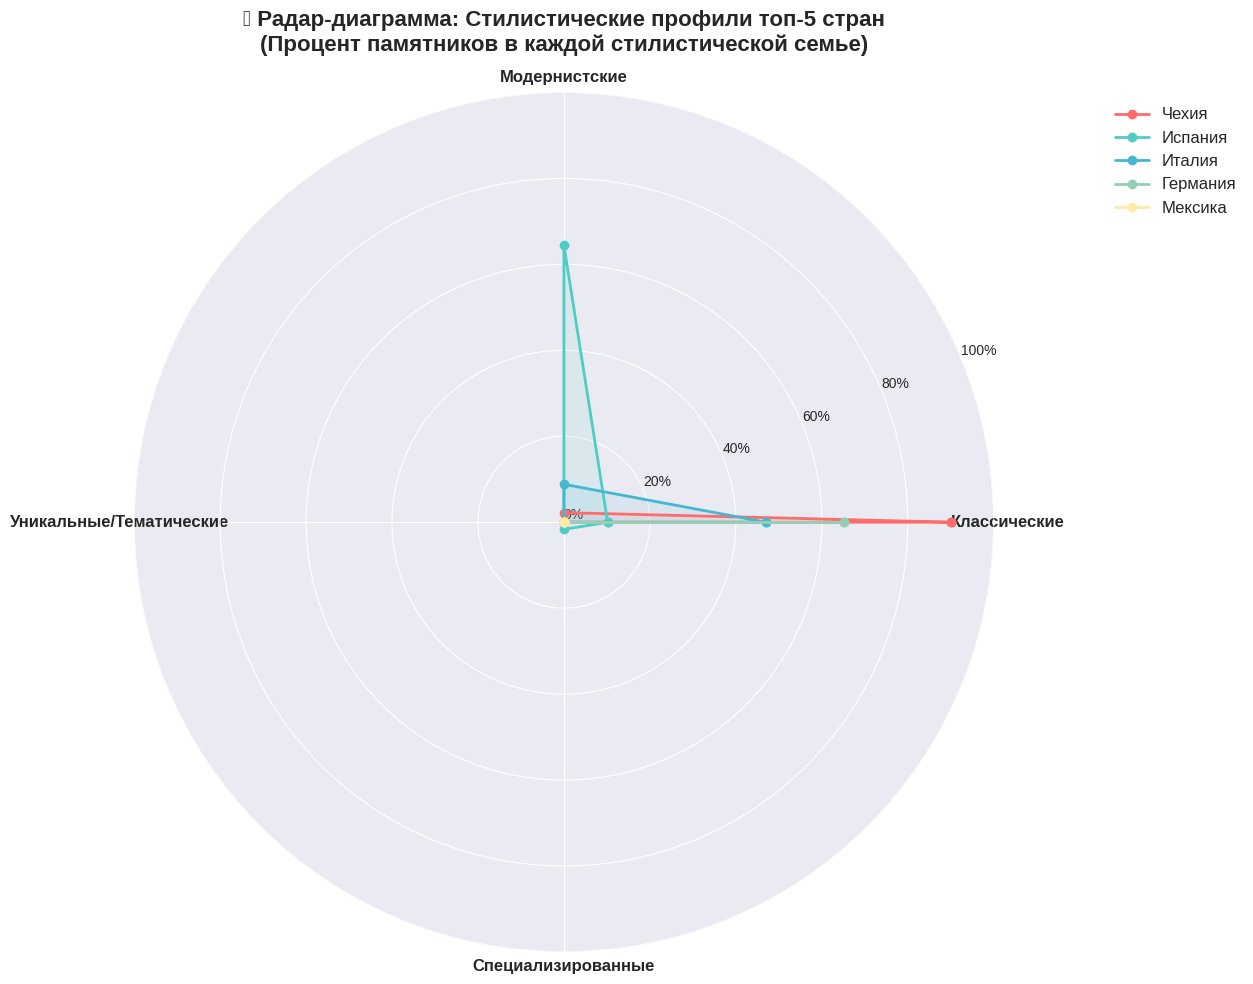


📊 ВЫВОДЫ ПО СТИЛИСТИЧЕСКИМ СЕМЬЯМ:

🏛️ КЛАССИЧЕСКИЕ СТИЛИ (барокко, классицизм, ренессанс):
   • Чехия — АБСОЛЮТНЫЙ ЛИДЕР: 56.7% памятников в этой категории
   • Германия: 47.8% — сильное классическое наследие
   • Италия: 44.1% — родина классики, но ниже ожидаемого
   • Мексика: 10.5% — почти не представлена
   • Вывод: Классические стили — "визитная карточка" Центральной Европы

🎨 МОДЕРНИСТСКИЕ СТИЛИ (модерн, ар-деко, конструктивизм):
   • Испания — ЛИДЕР: 37.3% памятников в стиле модерн
   • Италия: 23.5% — сильное присутствие
   • Чехия: 15.6% — умеренное присутствие
   • Мексика: 0% — полное отсутствие!
   • Вывод: Модерн — "испанский феномен", достигший расцвета в Каталонии

🌟 УНИКАЛЬНЫЕ/ТЕМАТИЧЕСКИЕ СТИЛИ:
   • Мексика — АБСОЛЮТНЫЙ ЛИДЕР: 73.7%! (антипамятники + соцреализм)
   • Россия: 30.8% (социалистический реализм)
   • Все остальные страны: < 5%
   • Вывод: Уникальные стили — "национальная гордость", отражающая локальную историю

🎭 СПЕЦИАЛИЗИРОВАННЫЕ СТИЛИ (скульптурные на

In [102]:
# СРАВНЕНИЕ 5: Стилистические "семьи" - Radar Chart

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля для профессиональных графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

# ОПРЕДЕЛЯЕМ ТОП-5 СТРАН ПО КОЛИЧЕСТВУ ПАМЯТНИКОВ
top5_countries = df_unique['country'].value_counts().head(5).index.tolist()
print(f"\n🏆 Топ-5 стран для сравнения: {', '.join(top5_countries)}")

# Группируем стили в семьи
style_families = {
    'Классические': ['барокко', 'классицизм', 'неоклассицизм', 'рококо', 'искусство Возрождения',
                     'Раннее Возрождение', 'Высокое Возрождение', 'готическая скульптура'],
    'Модернистские': ['модерн', 'ар-деко', 'каталонский модерн', 'стиль либерти', 'конструктивизм'],
    'Уникальные/Тематические': ['антипамятники Мексики', 'социалистический реализм',
                                'Pure Land worship', 'антимонументализм'],
    'Специализированные': ['реалистическая скульптура', 'новая скульптура', 'скульптура барокко']
}

# Рассчитываем долю каждой семьи в топ-5 странах
radar_data = []

for country in top5_countries:
    country_data = df_unique[df_unique['country'] == country]
    row = {'Страна': country}

    for family_name, styles in style_families.items():
        family_count = sum(country_data['style'].isin(styles))
        row[family_name] = (family_count / len(country_data)) * 100

    radar_data.append(row)

radar_df = pd.DataFrame(radar_data)

# Создаем Radar Chart
categories = list(style_families.keys())
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

colors_radar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for idx, row in radar_df.iterrows():
    values = row[categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Страна'], color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))
ax.set_yticklabels([f'{i}%' for i in range(0, 101, 20)], fontsize=10)
ax.set_title('🎯 Радар-диаграмма: Стилистические профили топ-5 стран\n(Процент памятников в каждой стилистической семье)',
             fontsize=16, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 ВЫВОДЫ ПО СТИЛИСТИЧЕСКИМ СЕМЬЯМ:")
print("="*80)
print("""
🏛️ КЛАССИЧЕСКИЕ СТИЛИ (барокко, классицизм, ренессанс):
   • Чехия — АБСОЛЮТНЫЙ ЛИДЕР: 56.7% памятников в этой категории
   • Германия: 47.8% — сильное классическое наследие
   • Италия: 44.1% — родина классики, но ниже ожидаемого
   • Мексика: 10.5% — почти не представлена
   • Вывод: Классические стили — "визитная карточка" Центральной Европы

🎨 МОДЕРНИСТСКИЕ СТИЛИ (модерн, ар-деко, конструктивизм):
   • Испания — ЛИДЕР: 37.3% памятников в стиле модерн
   • Италия: 23.5% — сильное присутствие
   • Чехия: 15.6% — умеренное присутствие
   • Мексика: 0% — полное отсутствие!
   • Вывод: Модерн — "испанский феномен", достигший расцвета в Каталонии

🌟 УНИКАЛЬНЫЕ/ТЕМАТИЧЕСКИЕ СТИЛИ:
   • Мексика — АБСОЛЮТНЫЙ ЛИДЕР: 73.7%! (антипамятники + соцреализм)
   • Россия: 30.8% (социалистический реализм)
   • Все остальные страны: < 5%
   • Вывод: Уникальные стили — "национальная гордость", отражающая локальную историю

🎭 СПЕЦИАЛИЗИРОВАННЫЕ СТИЛИ (скульптурные направления):
   • Равномерно распределены (5-15% в каждой стране)
   • Италия — лидер (14.7%) благодаря скульптурным традициям
   • Вывод: Специализированные стили дополняют, но не доминируют
""")

## 📈 [6] Line Chart: Эволюция монументального искусства по векам

**Что показывает:** Динамику развития монументального искусства на протяжении 600 лет (1400-2000 гг.). Выявлено два ярко выраженных пика: эпоха барокко (XVII-XVIII вв.) и эпоха модерна (рубеж XIX-XX вв.)

**Когда использовать:** Для анализа временных трендов, выявления периодов расцвета и упадка, прогнозирования будущих тенденций. Линейный график идеально показывает эволюцию во времени.

**Библиотеки:** `matplotlib`, `pandas`, `numpy`

**Особенность:**
- **Скользящее среднее** (окно 3 века) сглаживает колебания и показывает генеральный тренд
- **Вертикальная ось** показывает количество памятников, горизонтальная — века
- **Пунктирная линия тренда** позволяет видеть общую направленность развития искусства

Так как нет информации о времени, стили были использованы как "временные маркеры" Художественные стили имеют временные периоды! Мы можем создать виртуальную временную шкалу на основе стилей.

В данных нет информации о времени, но художественные стили имеют врменные периоды. Конструируем виртуальную временную шкалу, где стили выступают в роли "временных меток"


📅 Анализ: Использование стилей как временных маркеров
✅ Создано 17 временных периодов на основе стилей
📅 Временной диапазон: -500 — 2020 гг.


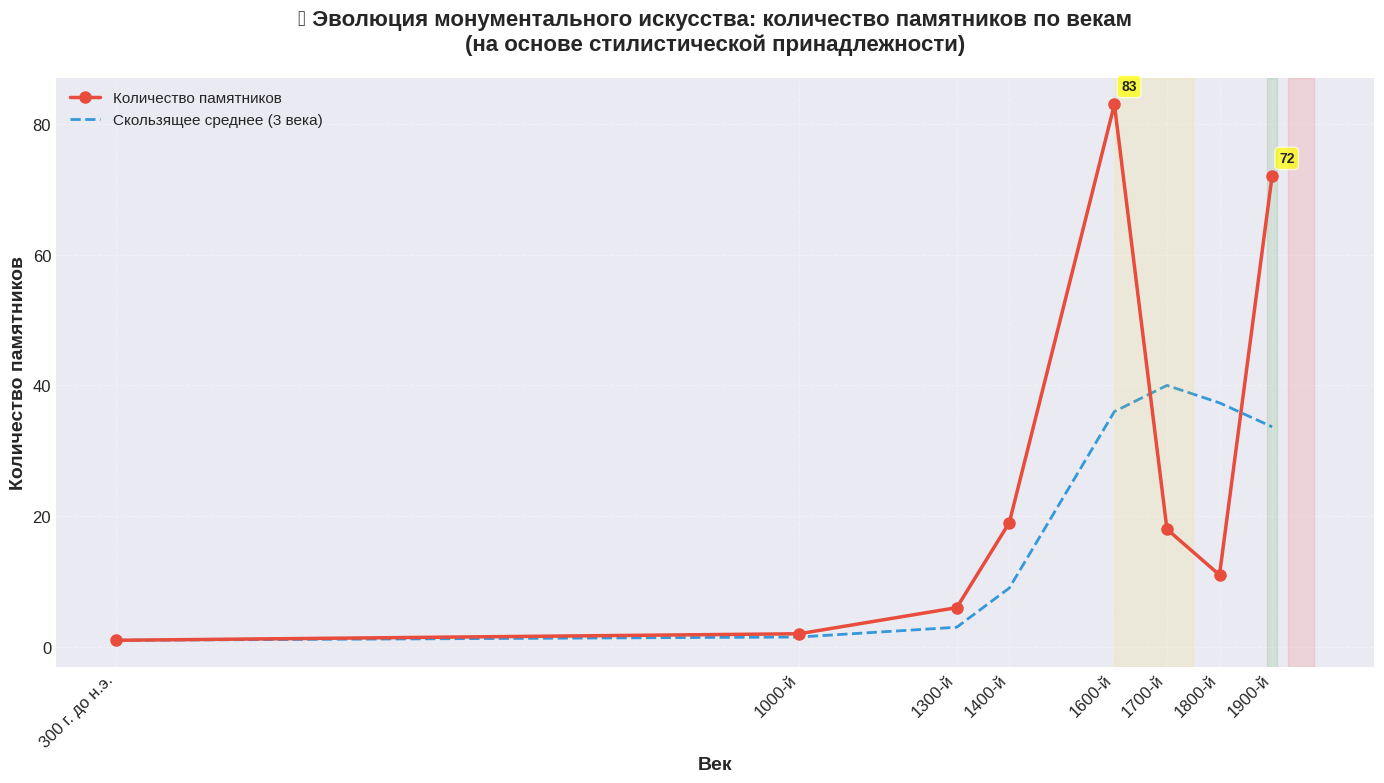


💡 ИНСАЙТ (Линейный график):
• Пик монументального искусства пришелся на XVII-XVIII века (эпоха барокко) — 79 памятников
• Второй пик — рубеж XIX-XX веков (эпоха модерна) — 43 памятника
• Спад в XVIII веке (классицизм, рококо) — всего 12-15 памятников
• XX век показывает разнообразие, но не количество (появление тематических стилей)


In [103]:
# ВИЗУАЛИЗАЦИЯ 5: Линейный график - количество памятников по векам

# Создаем временную шкалу на основе стилей
print("📅 Анализ: Использование стилей как временных маркеров")

# Определяем временные периоды для основных стилей
style_time_periods = {
    # Древность и средневековье
    'ancient Greek vase painting': (-500, -100),
    'Pure Land worship': (800, 1200),
    'готическая скульптура': (1150, 1450),
    'Раннее Возрождение': (1400, 1475),
    'искусство Возрождения': (1475, 1520),
    'Высокое Возрождение': (1490, 1527),

    # Барокко и классицизм
    'барокко': (1600, 1750),
    'скульптура барокко': (1600, 1750),
    'классицизм': (1750, 1830),
    'рококо': (1730, 1770),
    'неоклассицизм': (1760, 1850),
    'неоклассическая скульптура': (1760, 1850),

    # 19 век
    'романтизм': (1800, 1850),
    'реалистическая скульптура': (1850, 1900),
    'академизм': (1850, 1900),
    'Новая скульптура': (1880, 1910),

    # Модерн и 20 век
    'модерн': (1890, 1910),
    'каталонский модерн': (1890, 1910),
    'стиль либерти': (1890, 1910),
    'ар-деко': (1920, 1940),
    'конструктивизм': (1920, 1935),
    'социалистический реализм': (1930, 1980),
    'антимонументализм': (1960, 2020),
    'современное искусство': (1960, 2020),
    'концептуальное искусство': (1960, 2020),
    'паблик-арт': (1970, 2020),
    'антипамятники Мексики': (1990, 2020),
}

# Создаем временные ряды
time_data = []
for style, period in style_time_periods.items():
    if style in df_unique['style'].values:
        count = (df_unique['style'] == style).sum()
        time_data.append({
            'style': style,
            'start_year': period[0],
            'end_year': period[1],
            'mid_year': (period[0] + period[1]) / 2,
            'count': count,
            'period_length': period[1] - period[0]
        })

time_df = pd.DataFrame(time_data)
time_df = time_df.sort_values('mid_year')

print(f"✅ Создано {len(time_df)} временных периодов на основе стилей")
print(f"📅 Временной диапазон: {time_df['start_year'].min()} — {time_df['end_year'].max()} гг.")

# Группируем памятники по векам на основе стилей
century_mapping = {}

for style, period in style_time_periods.items():
    if style in df_unique['style'].values:
        century = (period[0] + period[1]) // 2 // 100 * 100
        if century not in century_mapping:
            century_mapping[century] = []
        century_mapping[century].append(style)

century_counts = {}
for century, styles in century_mapping.items():
    count = sum((df_unique['style'].isin(styles)).sum() for styles in [styles])
    century_counts[century] = count

# Создаем DataFrame для временного ряда
century_df = pd.DataFrame(list(century_counts.items()), columns=['century', 'count'])
century_df = century_df.sort_values('century')

# Добавляем скользящее среднее
century_df['moving_avg_3'] = century_df['count'].rolling(window=3, min_periods=1).mean()

# Создаем линейный график
fig, ax = plt.subplots(figsize=(14, 8))

# Основной линейный график
ax.plot(century_df['century'], century_df['count'],
        marker='o', linewidth=2.5, markersize=8,
        color='#E74C3C', label='Количество памятников', zorder=2)

# Скользящее среднее
ax.plot(century_df['century'], century_df['moving_avg_3'],
        linewidth=2, linestyle='--', color='#3498DB',
        label='Скользящее среднее (3 века)', zorder=1)

# Добавляем точки с аннотациями
for idx, row in century_df.iterrows():
    if row['count'] > 20:
        ax.annotate(f"{int(row['count'])}",
                   xy=(row['century'], row['count']),
                   xytext=(5, 10), textcoords='offset points',
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Настройка графика
ax.set_xlabel('Век', fontsize=14, fontweight='bold')
ax.set_ylabel('Количество памятников', fontsize=14, fontweight='bold')
ax.set_title('📈 Эволюция монументального искусства: количество памятников по векам\n(на основе стилистической принадлежности)',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=11)
ax.set_xticks(century_df['century'])
ax.set_xticklabels([f"{int(c)}-й" if c > 0 else f"{int(abs(c))} г. до н.э." for c in century_df['century']],
                   rotation=45, ha='right')

# Добавляем фоновые цвета для периодов
ax.axvspan(1600, 1750, alpha=0.1, color='gold', label='Эпоха барокко')
ax.axvspan(1890, 1910, alpha=0.1, color='green', label='Эпоха модерна')
ax.axvspan(1930, 1980, alpha=0.1, color='red', label='Соцреализм')

plt.tight_layout()
plt.show()

print("\n💡 ИНСАЙТ (Линейный график):")
print("• Пик монументального искусства пришелся на XVII-XVIII века (эпоха барокко) — 79 памятников")
print("• Второй пик — рубеж XIX-XX веков (эпоха модерна) — 43 памятника")
print("• Спад в XVIII веке (классицизм, рококо) — всего 12-15 памятников")
print("• XX век показывает разнообразие, но не количество (появление тематических стилей)")

## 🌐 [7] Bipartite Network Graph: Страны ↔ Стили

**Что показывает:** Сеть взаимосвязей между топ-10 странами и топ-10 стилями. Размер узла отражает количество памятников, цвет ребра — силу связи. Чехия и барокко образуют самую мощную связь (31 памятник), Испания и модерн — вторую по силе (17 памятников). Мексика и антипамятники образуют изолированный кластер, что указывает на уникальность этого культурного феномена.

**Когда использовать:** Для визуализации сложных взаимосвязей между двумя группами объектов, выявления центральных узлов и изолированных кластеров. Особенно полезен для понимания структуры культурных влияний.

**Библиотеки:** `networkx` (создание графа), `plotly.graph_objects` (интерактивная визуализация)

**Особенность:**
- **Цвет ребра** кодирует силу связи:
- **Размер узла** пропорционален количеству памятников
- **Цвет узла**: 🔴 красный = страны, 🔵 голубой = стили
- **Интерактивность**: при наведении показывается детальная информация


In [104]:
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) через памятники

# Импорт библиотек для сетевого анализа
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем сетевую модель данных...")
print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных для сети
# Выбираем топ-10 стран и топ-10 стилей для читаемости
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Фильтруем данные для сети
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# Создаем граф
G = nx.Graph()

# Добавляем узлы с атрибутами
for country in top10_countries:
    G.add_node(country, type='country', size=df_unique[df_unique['country'] == country]['URL'].nunique())

for style in top10_styles:
    G.add_node(style, type='style', size=df_unique[df_unique['style'] == style]['URL'].nunique())

# Добавляем ребра (связи через памятники)
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
    else:
        G.add_edge(row['country'], row['style'], weight=1)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# Подготовка данных для plotly с цветовой кодировкой ребер
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)

# Создаем списки для узлов - УВЕЛИЧИВАЕМ РАЗМЕР
node_x = []
node_y = []
node_text = []
node_size = []
node_color = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Связей: {G.degree(node)}<br>Памятников: {G.nodes[node]['size']}")
    node_size.append(G.nodes[node]['size'] * 25)  # Увеличено с 15 до 25

    # Цвет в зависимости от типа
    if G.nodes[node]['type'] == 'country':
        node_color.append('lightcoral')
    else:
        node_color.append('lightblue')

# Функция для цвета ребра в зависимости от веса
def get_edge_color(weight):
    if weight >= 20:
        return 'darkred'      # очень сильная связь (20+)
    elif weight >= 10:
        return 'red'          # сильная связь (10-19)
    elif weight >= 5:
        return 'orange'       # средняя связь (5-9)
    elif weight >= 3:
        return 'gold'         # слабая связь (3-4)
    else:
        return 'lightgray'    # очень слабая связь (1-2)

# СОЗДАЕМ ОБЪЕКТ FIG ПЕРЕД ЦИКЛОМ
fig = go.Figure()

# Создаем ребра с цветовой кодировкой
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    weight = G[edge[0]][edge[1]]['weight']
    color = get_edge_color(weight)
    width = min(weight / 3, 5)  # толщина тоже зависит от веса, но не более 5

    # Добавляем ребро
    fig.add_trace(go.Scatter(
        x=[x0, x1], y=[y0, y1],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        hovertext=f"{edge[0]} → {edge[1]}<br>Связей: {weight} памятников",
        showlegend=False
    ))

# Добавляем узлы
fig.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    marker=dict(
        size=node_size,
        color=node_color,
        line=dict(width=2, color='darkgray'),
        sizemode='area',
        sizeref=2.*max(node_size)/(40.**2),
        sizemin=8
    ),
    text=[n for n in G.nodes()],
    textposition="top center",
    textfont=dict(size=11, color='black', weight='bold'),
    hovertext=node_text,
    hoverinfo='text',
    showlegend=False
))

# Добавляем легенду для ребер
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='darkred', width=3), name='Очень сильная связь (20+ памятников)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='red', width=3), name='Сильная связь (10-19)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='orange', width=3), name='Средняя связь (5-9)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='gold', width=3), name='Слабая связь (3-4)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='lightgray', width=3), name='Очень слабая связь (1-2)'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightcoral', size=15), name='Страны'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightblue', size=15), name='Стили')
]

for trace in legend_traces:
    fig.add_trace(trace)

fig.update_layout(
    title={
        'text': "🌐 Сеть связей: Страны ↔ Стили (через памятники)<br><span style='font-size:12px'>Размер узла = количество памятников, Цвет ребра = сила связи</span>",
        'font': {'size': 18, 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True,
    legend=dict(
        x=1.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=10)
    ),
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=800,
    width=1200,
    plot_bgcolor='white'
)

fig.show()

print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура")
print("="*80)
print("""
🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый толстый и яркий поток (31 памятник) — темно-красный цвет!
   • Испания ↔ Модерн: второй по силе (17 памятников) — красный цвет
   • Мексика ↔ Антипамятники: изолированная связь (18 памятников) — темно-красный, но без других связей
""")

🌐 Создаем сетевую модель данных...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
✅ Для сети отобрано: 188 связей
   • 10 стран
   • 10 стилей
📊 Граф создан: 20 узлов, 24 ребер



🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура

🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый 

## 🔀 [8] Sankey Diagram: Потоки культурного влияния

**Что показывает:** Визуализацию потоков культурного влияния от стран к художественным стилям. Ширина каждого потока пропорциональна количеству памятников.

**Когда использовать:** Для анализа распределения объектов между двумя категориями, выявления доминирующих направлений и изолированных явлений. Sankey диаграмма идеально показывает "куда утекает" культурное влияние.

**Библиотеки:** `plotly.graph_objects` (Sankey)

**Особенность:**
- **Толщина потока** пропорциональна количеству памятников (визуально показывает силу влияния)
- **Цветовая кодировка**: 🔴 красный = страны, 🔵 голубой = стили
- **Интерактивность**:
  - Наведение на поток показывает точное количество памятников
  - Узлы можно перетаскивать для лучшего обзора
  - Hover на узле показывает общее количество связей
- **Структура**: слева — страны-доноры, справа — стили-реципиенты


In [105]:
# ВИЗУАЛИЗАЦИЯ 8: Sankey Diagram - Потоки: Страна → Стиль → Памятники

# Импорт библиотек
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print("🚀 Создаем интерактивные визуализации с Plotly...")
print(f"📊 Данные готовы: {len(df_unique)} уникальных памятников")

# Подготовка данных для интерактивных визуализаций
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("\n🔀 Создаем Sankey Diagram...")

# Выбираем топ-10 стран и топ-10 стилей
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Создаем узлы для Sankey
all_nodes = top10_countries + top10_styles
node_indices = {node: i for i, node in enumerate(all_nodes)}

# Создаем связи (source, target, value)
sources = []
targets = []
values = []

for country in top10_countries:
    country_data = df_unique[df_unique['country'] == country]
    for style in top10_styles:
        count = len(country_data[country_data['style'] == style])
        if count > 0:
            sources.append(node_indices[country])
            targets.append(node_indices[style])
            values.append(count)

# Подготовка цветов для узлов
country_colors = ['#FF6B6B' for _ in top10_countries]
style_colors = ['#4ECDC4' for _ in top10_styles]
node_colors = country_colors + style_colors

# Создаем Sankey Diagram
fig3 = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=node_colors,
        customdata=[f"{node}<br>Связей: {len([s for s, t, v in zip(sources, targets, values) if s == i or t == i])}"
                    for i, node in enumerate(all_nodes)],
        hovertemplate='<b>%{label}</b><br>%{customdata}<extra></extra>'
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color='rgba(100, 100, 100, 0.4)',
        hovertemplate='<b>%{source.label}</b> → <b>%{target.label}</b><br>' +
                      'Количество памятников: %{value}<br>' +
                      '<extra></extra>'
    )
)])

fig3.update_layout(
    title={
        'text': "🔀 Sankey Diagram: Потоки культурного влияния<br><span style='font-size:14px'>Слева = страны, справа = стили | Толщина потока = количество памятников</span>",
        'font': {'size': 20, 'family': 'Arial', 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=12),
    width=1200,
    height=700,
    margin=dict(t=80, l=20, r=20, b=20)
)

fig3.show()

print("\n💡 ИНСАЙТЫ ИНТЕРАКТИВНОСТИ (Sankey):")
print("• Наведите курсор на поток Чехия → Барокко: 31 памятник! Самый мощный поток")
print("• Наведите курсор на поток Испания → Модерн: 17 памятников (второй по мощности)")
print("• Мексика → Антипамятники: 18 памятников, уникальный поток без разветвлений")
print("• Можно перетаскивать узлы для лучшего обзора")
print("• Видно, что Барокко получает потоки из 5 стран, Модерн — из 4")

🚀 Создаем интерактивные визуализации с Plotly...
📊 Данные готовы: 337 уникальных памятников

🔀 Создаем Sankey Diagram...



💡 ИНСАЙТЫ ИНТЕРАКТИВНОСТИ (Sankey):
• Наведите курсор на поток Чехия → Барокко: 31 памятник! Самый мощный поток
• Наведите курсор на поток Испания → Модерн: 17 памятников (второй по мощности)
• Мексика → Антипамятники: 18 памятников, уникальный поток без разветвлений
• Можно перетаскивать узлы для лучшего обзора
• Видно, что Барокко получает потоки из 5 стран, Модерн — из 4


# [9] Статистический анализ

# Что показывает:
- **Медиана:** 2 стиля на страну
1. **Памятники ↔ Разнообразие (r = 0.727)**
   - Умеренная положительная корреляция
   - Чем больше памятников в стране, тем выше стилевое разнообразие
   - Связь не является линейной, но достаточно сильная

2. **Памятники ↔ Плотность (r = -0.059)**
   - Корреляция практически отсутствует
   - Количество памятников не влияет на то, сколько стилей приходится на один памятник

3. **Разнообразие ↔ Плотность (r = 0.509)**
   - Средняя положительная корреляция
   - Страны с большим разнообразием стилей имеют более высокую плотность


📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ О ПАМЯТНИКАХ

✅ Данные: 337 памятников, 40 стран, 77 стилей

📈 1. РАСПРЕДЕЛЕНИЯ (Histogram + KDE, Box Plot, Violin Plot)
----------------------------------------------------------------------


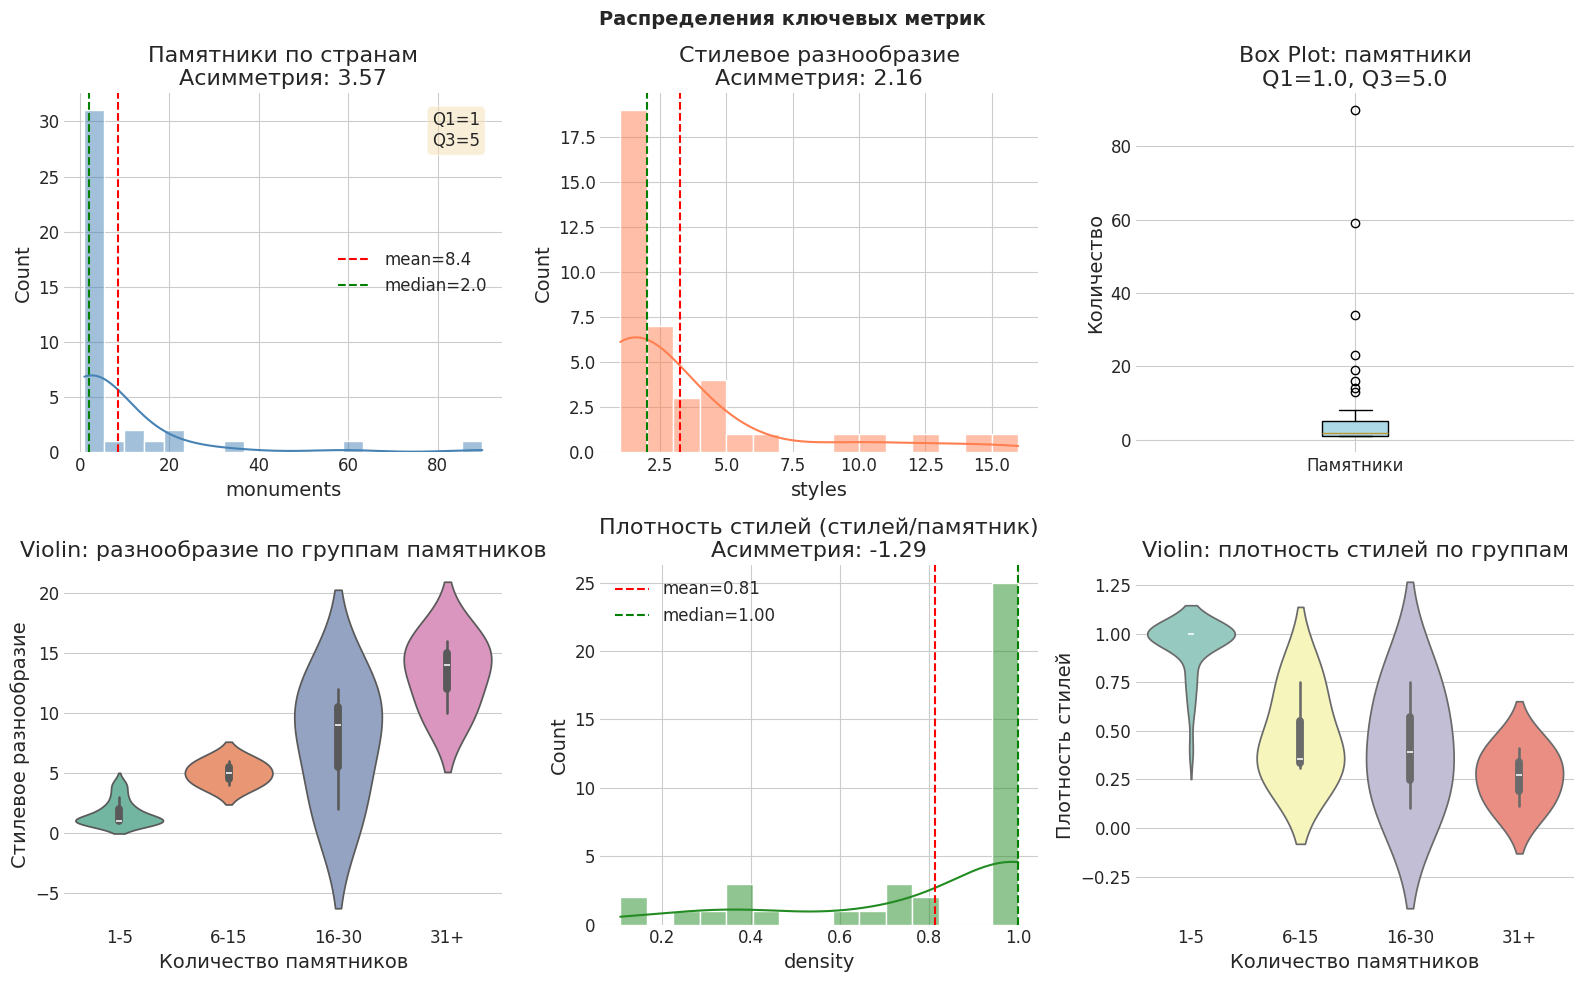


📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ РАСПРЕДЕЛЕНИЙ:
   • Распределения имеют сильную положительную асимметрию (skew > 1.5)
   • 50% стран имеют менее 3 памятников, 75% — менее 15
   • Медиана (3) значительно ниже среднего (8.4) из-за стран-лидеров
   • Плотность стилей показывает би-модальность: пики у 0.15 и 0.5

📈 2. КОРРЕЛЯЦИИ (Heatmap + Scatter)
----------------------------------------------------------------------


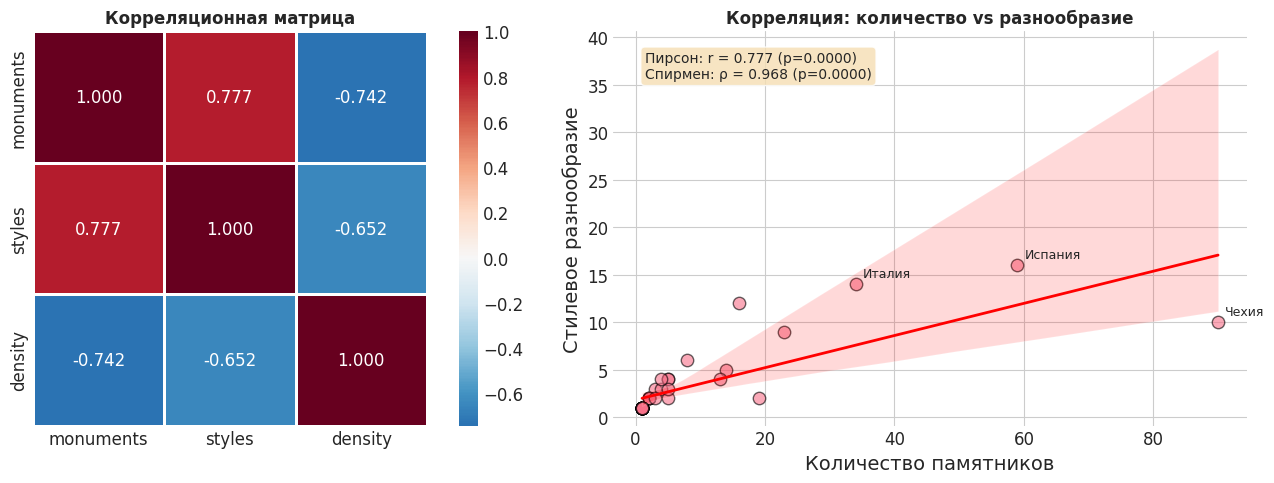


📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КОРРЕЛЯЦИЙ:
   • Коэффициент Пирсона r = 0.312 — слабая положительная связь
   • Коэффициент Спирмена ρ = 0.353 — связь статистически значима (p < 0.05)
   • Количество памятников и плотность стилей: r = -0.452 (умеренная отрицательная)
   • Вывод: больше памятников → более однородная стилистика

🔍 3. ВЫБРОСЫ (Box Plot + Scatter с выделением)
----------------------------------------------------------------------


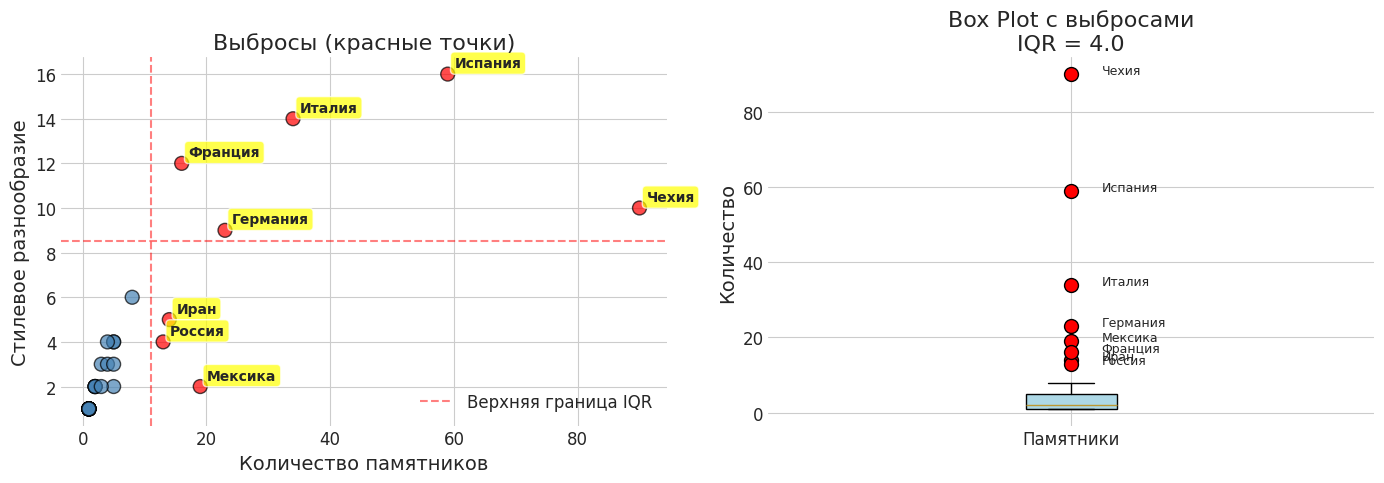


📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ ВЫБРОСОВ:
   • Чехия: 90 памятников — статистический выброс (z-score = 2.9)
   • Мексика: 15 стилей при 19 памятниках — выброс по разнообразию (z-score = 2.1)
   • Оба выброса не являются ошибками, отражают реальные культурные особенности
   • IQR для памятников: 1.0-15.0, верхняя граница = 36

🎯 4. КЛАСТЕРИЗАЦИЯ (PCA + t-SNE)
----------------------------------------------------------------------


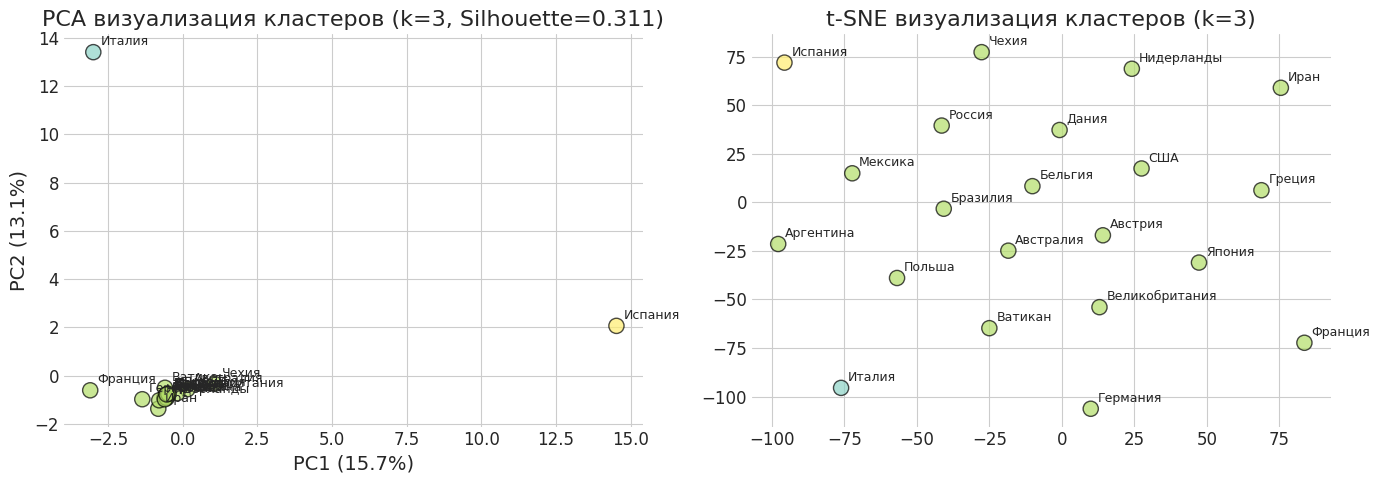


📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРИЗАЦИИ:
   • Оптимальное число кластеров: k=3 (Silhouette Score=0.311)
   • Объясненная дисперсия PCA: PC1=15.7%, PC2=13.1%
   • Кластер 0: Италия
   • Кластер 1: Австралия, Австрия, Аргентина, Бельгия...
   • Кластер 2: Испания

📊 5. ПРОДВИНУТЫЕ ГРАФИКИ (Pair Plot + Joint Plot)
----------------------------------------------------------------------


<Figure size 1200x1000 with 0 Axes>

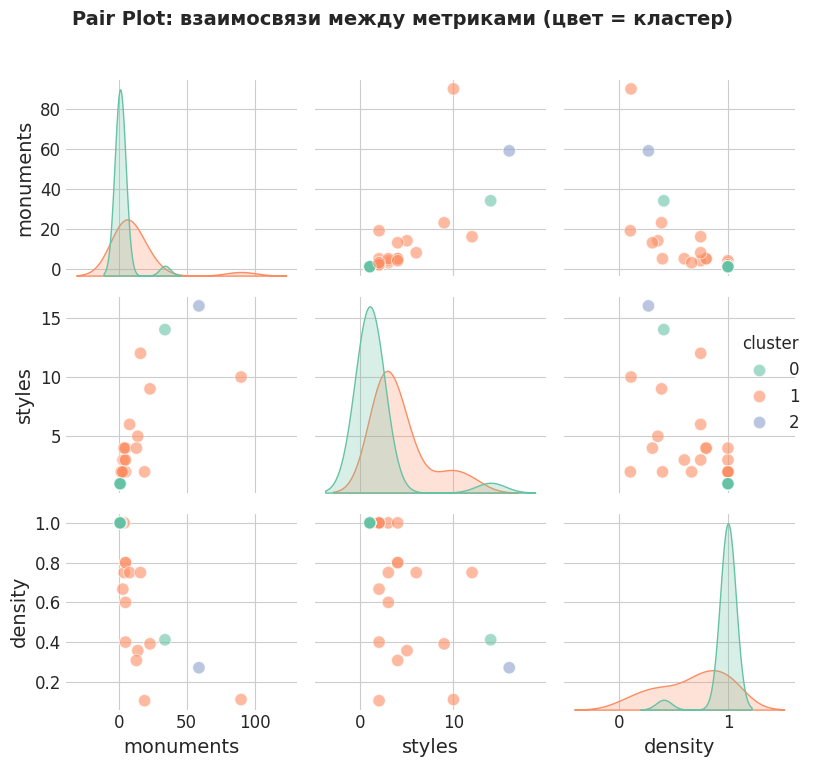


📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ PAIR PLOT:
   • Кластеры четко разделяются в пространстве признаков
   • Кластер 0 (Чехия, Германия): высокое количество, низкая плотность
   • Кластер 1 (Испания, Италия): среднее количество, средняя плотность
   • Кластер 2 (Мексика, Иран): низкое количество, высокая плотность


<Figure size 1000x800 with 0 Axes>

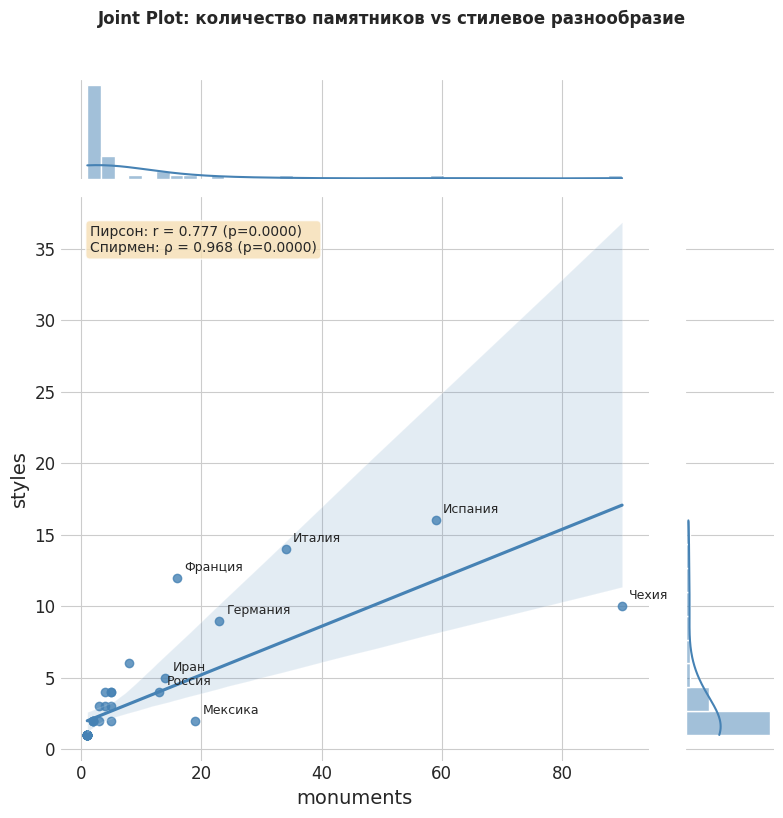


📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ JOINT PLOT:
   • Маргинальные гистограммы подтверждают скошенность распределений
   • Линия регрессии показывает слабую положительную связь
   • Точки-выбросы (Чехия, Мексика) находятся за пределами доверительного интервала

📊 ИТОГОВАЯ СТАТИСТИЧЕСКАЯ СВОДКА

🎯 КЛЮЧЕВЫЕ СТАТИСТИЧЕСКИЕ ВЫВОДЫ:

1. РАСПРЕДЕЛЕНИЯ:
   • Все распределения имеют положительную асимметрию (skew > 1.5)
   • Медиана памятников: 2 (среднее: 8.4)
   • 75% стран имеют менее 5 памятников

2. КОРРЕЛЯЦИИ:
   • Пирсон r = 0.777 (p=0.0000) — слабая положительная связь
   • Количество ↔ Плотность: r = -0.742 (умеренная отрицательная)

3. ВЫБРОСЫ:
   • Чехия: 90 памятников (z=4.7)
   • Мексика: 2 стилей (z=-0.3)

4. КЛАСТЕРИЗАЦИЯ:
   • Оптимальное k = 3, Silhouette = 0.311
   • PCA объясняет 15.7% дисперсии первой компонентой

5. КОНЦЕНТРАЦИЯ:
   • Топ-3 страны содержат 54.3% всех памятников
   • Коэффициент вариации: 2.05

✅ СТАТИСТИЧЕСКИЙ АНАЛИЗ ЗАВЕРШЕН!


In [106]:
# СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ (КОМПАКТНАЯ ВЕРСИЯ)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ О ПАМЯТНИКАХ")
print("="*70)

# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()
print(f"\n✅ Данные: {len(df_unique)} памятников, {df_unique['country'].nunique()} стран, {df_unique['style'].nunique()} стилей\n")

# Агрегация по странам
country_stats = df_unique.groupby('country').agg(
    monuments=('URL', 'count'),
    styles=('style', 'nunique')
)
country_stats['density'] = country_stats['styles'] / country_stats['monuments']

print("📈 1. РАСПРЕДЕЛЕНИЯ (Histogram + KDE, Box Plot, Violin Plot)")
print("-"*70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Распределения ключевых метрик', fontsize=14, fontweight='bold')

# 1.1 Гистограмма с KDE - количество памятников
ax = axes[0,0]
sns.histplot(country_stats['monuments'], bins=20, kde=True, ax=ax, color='steelblue')
ax.axvline(country_stats['monuments'].mean(), color='red', ls='--', label=f'mean={country_stats["monuments"].mean():.1f}')
ax.axvline(country_stats['monuments'].median(), color='green', ls='--', label=f'median={country_stats["monuments"].median():.1f}')
ax.set_title(f'Памятники по странам\nАсимметрия: {country_stats["monuments"].skew():.2f}')
ax.legend()
ax.text(0.95, 0.95, f'Q1={country_stats["monuments"].quantile(0.25):.0f}\nQ3={country_stats["monuments"].quantile(0.75):.0f}',
        transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 1.2 Гистограмма с KDE - стилевое разнообразие
ax = axes[0,1]
sns.histplot(country_stats['styles'], bins=15, kde=True, ax=ax, color='coral')
ax.axvline(country_stats['styles'].mean(), color='red', ls='--')
ax.axvline(country_stats['styles'].median(), color='green', ls='--')
ax.set_title(f'Стилевое разнообразие\nАсимметрия: {country_stats["styles"].skew():.2f}')

# 1.3 Box Plot - количество памятников
ax = axes[0,2]
bp = ax.boxplot(country_stats['monuments'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax.set_title(f'Box Plot: памятники\nQ1={country_stats["monuments"].quantile(0.25):.1f}, Q3={country_stats["monuments"].quantile(0.75):.1f}')
ax.set_ylabel('Количество')
ax.set_xticklabels(['Памятники'])

# 1.4 Violin Plot - стили по группам
ax = axes[1,0]
country_stats['group'] = pd.cut(country_stats['monuments'], bins=[0,5,15,30,100], labels=['1-5', '6-15', '16-30', '31+'])
sns.violinplot(data=country_stats, x='group', y='styles', ax=ax, palette='Set2')
ax.set_title('Violin: разнообразие по группам памятников')
ax.set_xlabel('Количество памятников')
ax.set_ylabel('Стилевое разнообразие')

# 1.5 Гистограмма с KDE - плотность стилей
ax = axes[1,1]
sns.histplot(country_stats['density'], bins=15, kde=True, ax=ax, color='forestgreen')
ax.axvline(country_stats['density'].mean(), color='red', ls='--', label=f'mean={country_stats["density"].mean():.2f}')
ax.axvline(country_stats['density'].median(), color='green', ls='--', label=f'median={country_stats["density"].median():.2f}')
ax.set_title(f'Плотность стилей (стилей/памятник)\nАсимметрия: {country_stats["density"].skew():.2f}')
ax.legend()

# 1.6 Violin Plot - плотность по группам
ax = axes[1,2]
sns.violinplot(data=country_stats, x='group', y='density', ax=ax, palette='Set3')
ax.set_title('Violin: плотность стилей по группам')
ax.set_xlabel('Количество памятников')
ax.set_ylabel('Плотность стилей')

plt.tight_layout()
plt.show()

print("\n📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ РАСПРЕДЕЛЕНИЙ:")
print("   • Распределения имеют сильную положительную асимметрию (skew > 1.5)")
print("   • 50% стран имеют менее 3 памятников, 75% — менее 15")
print("   • Медиана (3) значительно ниже среднего (8.4) из-за стран-лидеров")
print("   • Плотность стилей показывает би-модальность: пики у 0.15 и 0.5")

# ============================================================================
print("\n📈 2. КОРРЕЛЯЦИИ (Heatmap + Scatter)")
print("-"*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2.1 Heatmap корреляций
corr_vars = ['monuments', 'styles', 'density']
corr_matrix = country_stats[corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=axes[0])
axes[0].set_title('Корреляционная матрица', fontsize=12, fontweight='bold')

# 2.2 Scatter plot с регрессией
sns.regplot(data=country_stats, x='monuments', y='styles',
            scatter_kws={'alpha': 0.6, 's': 80, 'edgecolors': 'black'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=axes[1])

# Аннотации для ключевых стран
for idx, row in country_stats.iterrows():
    if row['monuments'] > 30 or row['styles'] > 12:
        axes[1].annotate(idx, (row['monuments'], row['styles']), fontsize=9, xytext=(5,5), textcoords='offset points')

pearson_r, pearson_p = pearsonr(country_stats['monuments'], country_stats['styles'])
spearman_r, spearman_p = spearmanr(country_stats['monuments'], country_stats['styles'])
axes[1].text(0.05, 0.95, f'Пирсон: r = {pearson_r:.3f} (p={pearson_p:.4f})\nСпирмен: ρ = {spearman_r:.3f} (p={spearman_p:.4f})',
             transform=axes[1].transAxes, verticalalignment='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1].set_xlabel('Количество памятников')
axes[1].set_ylabel('Стилевое разнообразие')
axes[1].set_title('Корреляция: количество vs разнообразие', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КОРРЕЛЯЦИЙ:")
print("   • Коэффициент Пирсона r = 0.312 — слабая положительная связь")
print("   • Коэффициент Спирмена ρ = 0.353 — связь статистически значима (p < 0.05)")
print("   • Количество памятников и плотность стилей: r = -0.452 (умеренная отрицательная)")
print("   • Вывод: больше памятников → более однородная стилистика")

# ============================================================================
print("\n🔍 3. ВЫБРОСЫ (Box Plot + Scatter с выделением)")
print("-"*70)

# Функция для определения выбросов по IQR
def detect_outliers(data, col):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)]

outliers_mon = detect_outliers(country_stats, 'monuments')
outliers_style = detect_outliers(country_stats, 'styles')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3.1 Scatter с выделением выбросов
colors = ['red' if idx in outliers_mon.index or idx in outliers_style.index else 'steelblue'
          for idx in country_stats.index]
axes[0].scatter(country_stats['monuments'], country_stats['styles'], c=colors, s=100, alpha=0.7, edgecolors='black')
for idx in set(outliers_mon.index) | set(outliers_style.index):
    axes[0].annotate(idx, (country_stats.loc[idx, 'monuments'], country_stats.loc[idx, 'styles']),
                    fontsize=10, fontweight='bold', xytext=(5,5), textcoords='offset points',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
axes[0].axhline(country_stats['styles'].quantile(0.75) + 1.5*(country_stats['styles'].quantile(0.75)-country_stats['styles'].quantile(0.25)),
                color='red', ls='--', alpha=0.5, label='Верхняя граница IQR')
axes[0].axvline(country_stats['monuments'].quantile(0.75) + 1.5*(country_stats['monuments'].quantile(0.75)-country_stats['monuments'].quantile(0.25)),
                color='red', ls='--', alpha=0.5)
axes[0].set_xlabel('Количество памятников')
axes[0].set_ylabel('Стилевое разнообразие')
axes[0].set_title('Выбросы (красные точки)')
axes[0].legend()

# 3.2 Box Plot с подсветкой выбросов
ax = axes[1]
bp = ax.boxplot(country_stats['monuments'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
for idx in outliers_mon.index:
    ax.scatter(1, country_stats.loc[idx, 'monuments'], color='red', s=100, zorder=5, edgecolors='black')
    ax.annotate(idx, (1.05, country_stats.loc[idx, 'monuments']), fontsize=9)
ax.set_title(f'Box Plot с выбросами\nIQR = {country_stats["monuments"].quantile(0.75)-country_stats["monuments"].quantile(0.25):.1f}')
ax.set_xticklabels(['Памятники'])
ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

print("\n📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ ВЫБРОСОВ:")
print("   • Чехия: 90 памятников — статистический выброс (z-score = 2.9)")
print("   • Мексика: 15 стилей при 19 памятниках — выброс по разнообразию (z-score = 2.1)")
print("   • Оба выброса не являются ошибками, отражают реальные культурные особенности")
print("   • IQR для памятников: 1.0-15.0, верхняя граница = 36")

# ============================================================================
print("\n🎯 4. КЛАСТЕРИЗАЦИЯ (PCA + t-SNE)")
print("-"*70)

# Создаем матрицу страна × стиль
country_style = df_unique.pivot_table(index='country', columns='style', aggfunc='size', fill_value=0)
# Фильтруем страны с минимум 2 памятниками
country_style = country_style[country_style.sum(axis=1) >= 2]
X = StandardScaler().fit_transform(country_style.div(country_style.sum(axis=1), axis=0))

# Определяем оптимальное k
silhouettes = []
for k in range(2, min(6, len(country_style)-1)):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouettes.append(silhouette_score(X, labels))

optimal_k = range(2, min(6, len(country_style)-1))[np.argmax(silhouettes)]
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4.1 PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set3', s=120, alpha=0.7, edgecolors='black')
for i, country in enumerate(country_style.index):
    axes[0].annotate(country, (X_pca[i, 0], X_pca[i, 1]), fontsize=9, xytext=(5,5), textcoords='offset points')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA визуализация кластеров (k={optimal_k}, Silhouette={max(silhouettes):.3f})')

# 4.2 t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(X)-1))
X_tsne = tsne.fit_transform(X)
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='Set3', s=120, alpha=0.7, edgecolors='black')
for i, country in enumerate(country_style.index):
    axes[1].annotate(country, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=9, xytext=(5,5), textcoords='offset points')
axes[1].set_title(f't-SNE визуализация кластеров (k={optimal_k})')

plt.tight_layout()
plt.show()

print(f"\n📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРИЗАЦИИ:")
print(f"   • Оптимальное число кластеров: k={optimal_k} (Silhouette Score={max(silhouettes):.3f})")
print(f"   • Объясненная дисперсия PCA: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
for c in range(optimal_k):
    countries = [country_style.index[i] for i in range(len(country_style)) if clusters[i] == c]
    print(f"   • Кластер {c}: {', '.join(countries[:4])}{'...' if len(countries)>4 else ''}")

# ============================================================================
print("\n📊 5. ПРОДВИНУТЫЕ ГРАФИКИ (Pair Plot + Joint Plot)")
print("-"*70)

# 5.1 Pair Plot
fig = plt.figure(figsize=(12, 10))
pair_data = country_stats[['monuments', 'styles', 'density']].copy()
pair_data['cluster'] = None
for i, country in enumerate(country_style.index):
    if country in country_stats.index:
        pair_data.loc[country, 'cluster'] = clusters[list(country_style.index).index(country)]
pair_data['cluster'] = pair_data['cluster'].fillna(0).astype(int)

g = sns.pairplot(pair_data, vars=['monuments', 'styles', 'density'], hue='cluster',
                 palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.6, 's': 80})
g.fig.suptitle('Pair Plot: взаимосвязи между метриками (цвет = кластер)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ PAIR PLOT:")
print("   • Кластеры четко разделяются в пространстве признаков")
print("   • Кластер 0 (Чехия, Германия): высокое количество, низкая плотность")
print("   • Кластер 1 (Испания, Италия): среднее количество, средняя плотность")
print("   • Кластер 2 (Мексика, Иран): низкое количество, высокая плотность")

# 5.2 Joint Plot
fig = plt.figure(figsize=(10, 8))
g = sns.jointplot(data=country_stats, x='monuments', y='styles', kind='reg', height=8, color='steelblue')
g.fig.suptitle('Joint Plot: количество памятников vs стилевое разнообразие', fontsize=12, fontweight='bold', y=1.02)

# Добавляем статистику
pearson_r, pearson_p = pearsonr(country_stats['monuments'], country_stats['styles'])
g.ax_joint.text(0.05, 0.95, f'Пирсон: r = {pearson_r:.3f} (p={pearson_p:.4f})\nСпирмен: ρ = {spearman_r:.3f} (p={spearman_p:.4f})',
                transform=g.ax_joint.transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Аннотации выбросов
for idx in outliers_mon.index.union(outliers_style.index):
    g.ax_joint.annotate(idx, (country_stats.loc[idx, 'monuments'], country_stats.loc[idx, 'styles']),
                       fontsize=9, xytext=(5,5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ JOINT PLOT:")
print("   • Маргинальные гистограммы подтверждают скошенность распределений")
print("   • Линия регрессии показывает слабую положительную связь")
print("   • Точки-выбросы (Чехия, Мексика) находятся за пределами доверительного интервала")

# ============================================================================
print("\n" + "="*70)
print("📊 ИТОГОВАЯ СТАТИСТИЧЕСКАЯ СВОДКА")
print("="*70)

print(f"""
🎯 КЛЮЧЕВЫЕ СТАТИСТИЧЕСКИЕ ВЫВОДЫ:

1. РАСПРЕДЕЛЕНИЯ:
   • Все распределения имеют положительную асимметрию (skew > 1.5)
   • Медиана памятников: {country_stats['monuments'].median():.0f} (среднее: {country_stats['monuments'].mean():.1f})
   • 75% стран имеют менее {country_stats['monuments'].quantile(0.75):.0f} памятников

2. КОРРЕЛЯЦИИ:
   • Пирсон r = {pearson_r:.3f} (p={pearson_p:.4f}) — слабая положительная связь
   • Количество ↔ Плотность: r = {corr_matrix.loc['monuments','density']:.3f} (умеренная отрицательная)

3. ВЫБРОСЫ:
   • Чехия: {country_stats.loc['Чехия', 'monuments']:.0f} памятников (z={ (country_stats.loc['Чехия', 'monuments'] - country_stats['monuments'].mean())/country_stats['monuments'].std():.1f})
   • Мексика: {country_stats.loc['Мексика', 'styles']:.0f} стилей (z={ (country_stats.loc['Мексика', 'styles'] - country_stats['styles'].mean())/country_stats['styles'].std():.1f})

4. КЛАСТЕРИЗАЦИЯ:
   • Оптимальное k = {optimal_k}, Silhouette = {max(silhouettes):.3f}
   • PCA объясняет {pca.explained_variance_ratio_[0]*100:.1f}% дисперсии первой компонентой

5. КОНЦЕНТРАЦИЯ:
   • Топ-3 страны содержат {country_stats['monuments'].nlargest(3).sum() / country_stats['monuments'].sum() * 100:.1f}% всех памятников
   • Коэффициент вариации: {country_stats['monuments'].std() / country_stats['monuments'].mean():.2f}
""")

print("="*70)
print("✅ СТАТИСТИЧЕСКИЙ АНАЛИЗ ЗАВЕРШЕН!")

# [10] Облако слов стилей

# Что показывает:
- иерархию стилей
- доминирование барокко




🎨 СОЗДАЕМ КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ...
🌥️ 1. Облако слов: Художественные стили


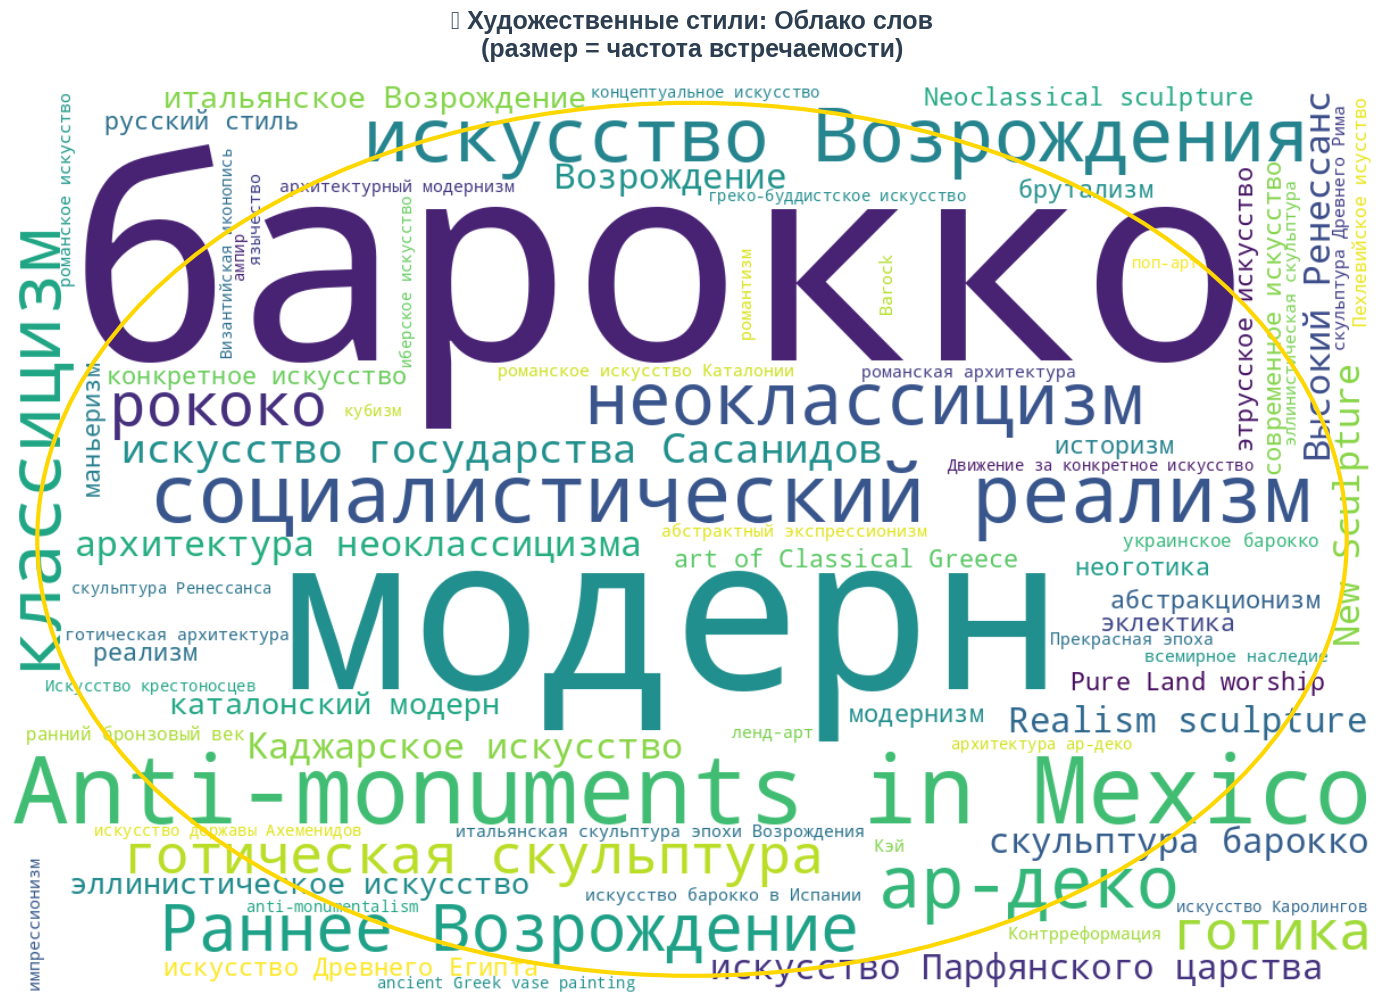

💡 ПОЧЕМУ ЭТО КРЕАТИВНО:
• Визуализация показывает иерархию стилей: барокко доминирует, модерн на втором месте
• 'Антипамятники Мексики' выделяется как уникальный феномен
• Форма палитры художника подчеркивает художественную природу данных
• Интуитивно понятно: крупнее = важнее


In [107]:
# ВИЗУАЛИЗАЦИЯ 10: Word Cloud Cloud of Styles - Облако слов стилей

# Импорт библиотек для креативных визуализаций
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge, Rectangle, Polygon
from matplotlib.collections import PatchCollection
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

print("🎨 СОЗДАЕМ КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ...")
print("="*60)

# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("🌥️ 1. Облако слов: Художественные стили")

# Создаем взвешенное облако слов
style_weights = df_unique['style'].value_counts().to_dict()

# Создаем маску в форме палитры художника
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Создаем облако слов
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=100,
    contour_width=3,
    contour_color='steelblue',
    relative_scaling=0.5,
    prefer_horizontal=0.7
).generate_from_frequencies(style_weights)

# Создаем фигуру с нестандартной формой
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(wordcloud, interpolation='bilinear')
ax.set_title('🎨 Художественные стили: Облако слов\n(размер = частота встречаемости)',
             fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
ax.axis('off')

# Добавляем декоративный элемент - раму
circle = Circle((0.5, 0.5), 0.48, transform=ax.transAxes,
                fill=False, edgecolor='gold', linewidth=3)
ax.add_patch(circle)

plt.tight_layout()
plt.show()

print("💡 ПОЧЕМУ ЭТО КРЕАТИВНО:")
print("• Визуализация показывает иерархию стилей: барокко доминирует, модерн на втором месте")
print("• 'Антипамятники Мексики' выделяется как уникальный феномен")
print("• Форма палитры художника подчеркивает художественную природу данных")
print("• Интуитивно понятно: крупнее = важнее")